# Using the TEM class for data inversion
## Profile data with sTEM profiler

We make use of the data published by Madsen et al. (2026), made publicly available on [Zenodo](https://doi.org/10.5281/zenodo.16894039). Here we focus on the sTEM profiler data with 3x3m loops, separated by 13m. Here, we used the file `sTEM.xyz` in the folder `SallingKirkeby_sTEM_0034_Profier`, renamed as `profiler.xyz`.

We import the main class `TEM`.

In [1]:
from tem import TEM

The instance is instantiated through the data file name. Instead of the USF files, we chose the xyz data files as it includes all soundings in one go. Whereas the data are in the xyz file, a gex file is exported containing the geometry of the loops, the time gates and the current waveform. If a file with the same name like the xyz file but the ending gex is found, it is read by default. Alternatively, you can specify this file explicitly by `cfg=`.

In [6]:
tem = TEM("data/Madsen2026/profiler.xyz")
print(tem)

TEM profile with 104 soundings
28 times (1.097112e-05-0.002367231)


The file contains 104 soundings with 28 time gates.
In the file, there are also the GPS positions that can be shown:

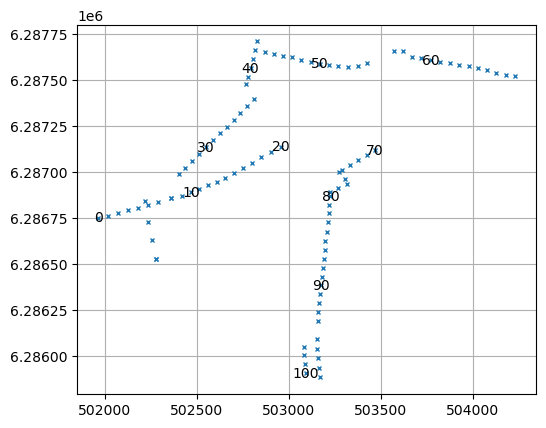

In [8]:
tem.showPositions();

By comparing to Figure 2, the first 20 soundings correspond to the beginnning of profile B, whose results are provided in Figure 5c (first 1200m). We extract those first soundings by

In [9]:
tem.filter(nmax=20)

We can show a single sounding by `showSounding()`

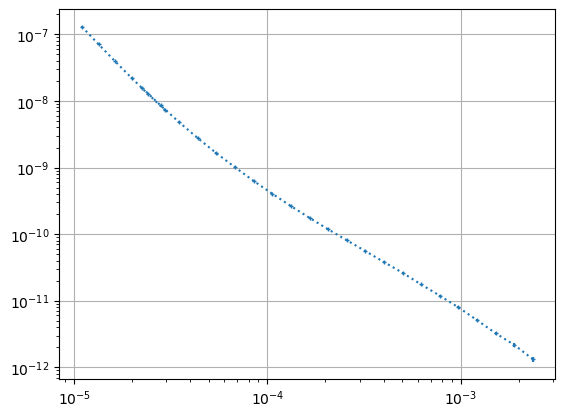

In [13]:
tem.showSounding(n=0);

or, transferred to apparent resistivity

<Axes: >

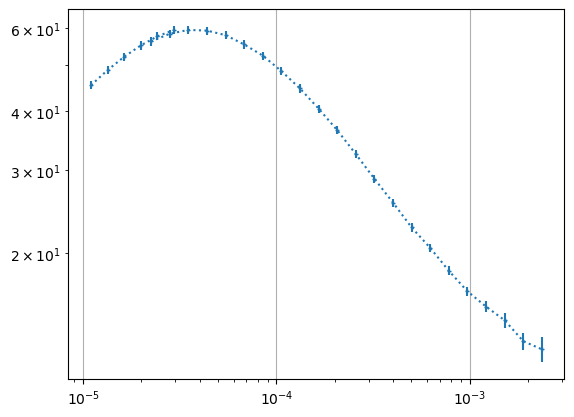

In [14]:
tem.showSounding(n=0, rhoa=True)

To view all data, we can use `showRhoa()`

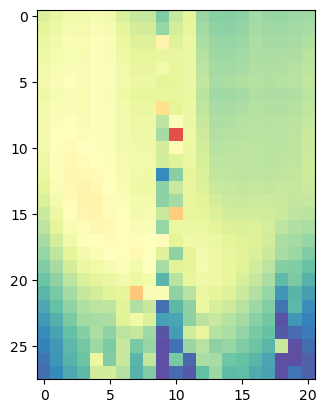

In [16]:
tem.showRhoa()

and observe that soundings 9 and 10 seem to be noisy, also indicated in Fig. 4a for deletion. So we delete thos two.

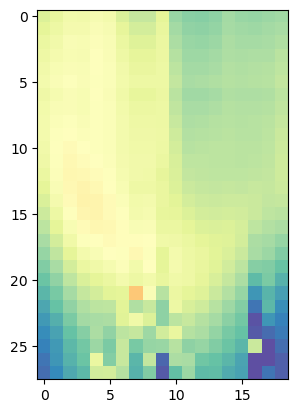

In [17]:
tem.filter(n=[9, 10])
tem.showRhoa();

Showing all soundings by

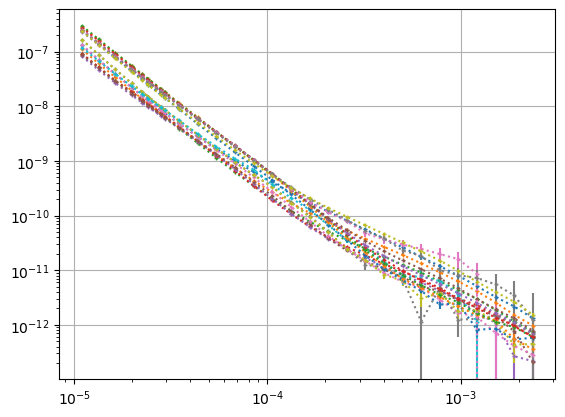

In [18]:
tem.showSoundings();

we observe them running into noise at around 1ms, which can be filtered by `.filter(tmax=1e-3)`. (TODO)

First, we invert a single sounding.

18/03/26 - 21:39:31 - pyGIMLi - INFO - Starting inversion.


fop: <stem.sTEMRhoModelling object at 0x0000019AC2F31B70>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 1.3e-12/1.3e-07
min/max (error): 3%/8.93%
min/max (start model): 250/250
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  518.46
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  279.40 (dPhi = 45.91%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   16.89 (dPhi = 92.38%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    3.57 (dPhi = 75.11%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    0.58 (dPhi = 62.69%) lam: 20.0


################################################################################
#                  Abort cr

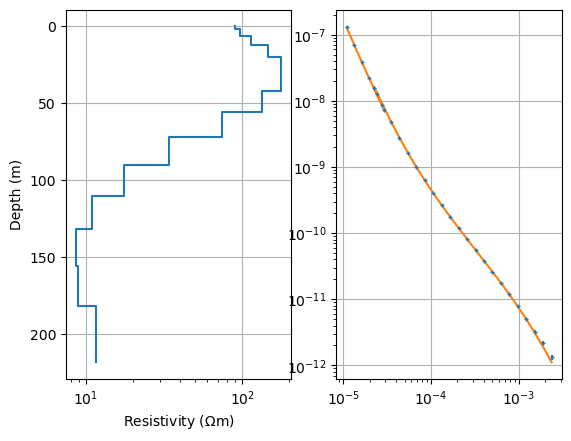

In [19]:
tem.invertSounding(0);

and see the change from the resistive (>100$\Omega$m) top layer to the conductive layer below (cf. Fig. 4c).
For inverting all soundings subsequently, we use 

18/03/26 - 21:42:16 - pyGIMLi - INFO - Starting inversion.


fop: <stem.sTEMRhoModelling object at 0x0000019AC2F31B70>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 1.3e-12/1.3e-07
min/max (error): 3%/8.93%
min/max (start model): 250/250
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  518.46
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  279.40 (dPhi = 45.91%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   16.89 (dPhi = 92.38%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    3.57 (dPhi = 75.11%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    0.58 (dPhi = 62.69%) lam: 20.0


################################################################################
#                  Abort cr

18/03/26 - 21:42:39 - pyGIMLi - INFO - 1: chi2=0.34 (2 iter)


18/03/26 - 21:42:43 - pyGIMLi - INFO - 2: chi2=0.45 (2 iter)


18/03/26 - 21:42:48 - pyGIMLi - INFO - 3: chi2=0.63 (2 iter)


...

18/03/26 - 21:43:02 - pyGIMLi - INFO - 5: chi2=1.17 (3 iter)
18/03/26 - 21:43:16 - pyGIMLi - INFO - 6: chi2=1.79 (4 iter)
18/03/26 - 21:43:25 - pyGIMLi - INFO - 7: chi2=2.45 (3 iter)
18/03/26 - 21:43:34 - pyGIMLi - INFO - 8: chi2=2.52 (3 iter)
18/03/26 - 21:43:38 - pyGIMLi - INFO - 9: chi2=0.97 (2 iter)


18/03/26 - 21:43:48 - pyGIMLi - INFO - 10: chi2=3.03 (3 iter)
18/03/26 - 21:44:02 - pyGIMLi - INFO - 11: chi2=2.32 (4 iter)
18/03/26 - 21:44:15 - pyGIMLi - INFO - 12: chi2=1.92 (4 iter)
18/03/26 - 21:44:25 - pyGIMLi - INFO - 13: chi2=1.16 (3 iter)
18/03/26 - 21:44:34 - pyGIMLi - INFO - 14: chi2=0.87 (3 iter)


18/03/26 - 21:44:35 - pyGIMLi - INFO - 15: chi2=0.80 (1 iter)


18/03/26 - 21:44:49 - pyGIMLi - INFO - 16: chi2=1.42 (4 iter)
18/03/26 - 21:44:50 - pyGIMLi - INFO - 17: chi2=0.63 (1 iter)


18/03/26 - 21:45:15 - pyGIMLi - INFO - 18: chi2=0.83 (6 iter)


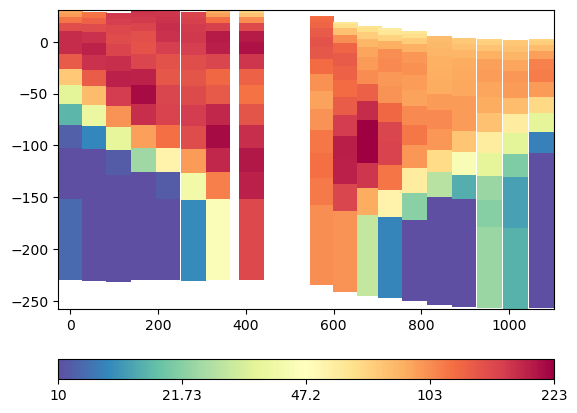

In [20]:
tem.invertAll();

By default, the elevation is extracted and the profile distance is computed by summing the distances.
By calling `showResults(usepos='x')`, one can also use Easting or Northing (`usepos='y'`) for display or `usepos=False` for not using any position. You can also specify the color map and color range.

<Axes: >

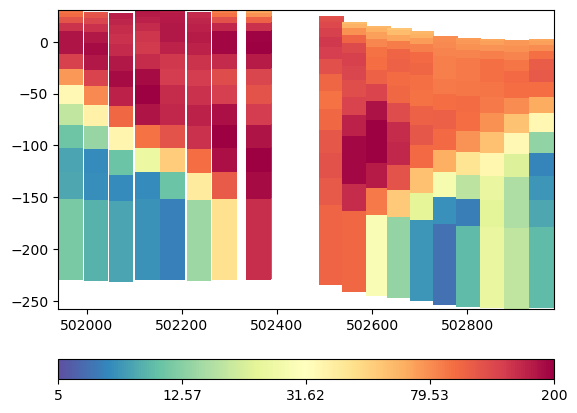

In [24]:
tem.showResults(cMin=5, cMax=200, cMap="Spectral_r", usepos='x')

Like for the inloop data, one can look at the waveform, which is taken into account.

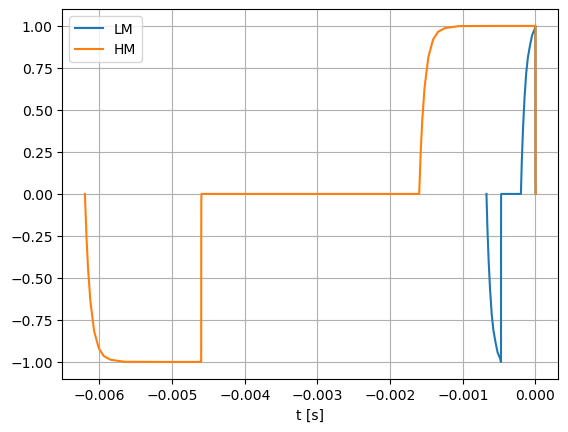

In [26]:
ax = tem.showWaveform();

(0.0, 1.0)

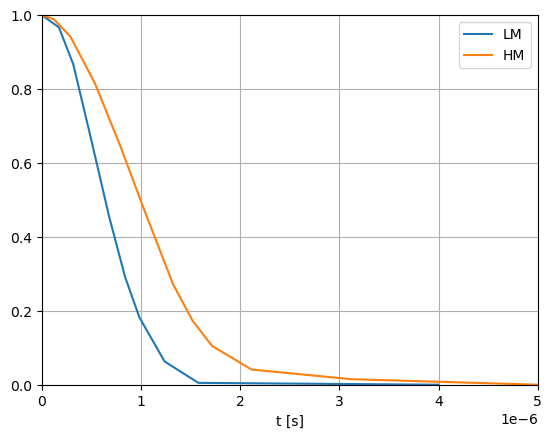

In [27]:
ax = tem.showWaveform();
ax.set_xlim(0, 5e-6)
ax.set_ylim(0, 1)

## References
Madsen, L.M., Almpanis, A., Storm, F. & Pedersen, J.B. (2026): A Hydrogeophysical Survey Utilising the sTEM and sTEMprofiler Systems: Transient Electromagnetic Data and Resistivity Models. Geoscience Data Journal, [doi:10.1002/gdj3.70067](https://doi.org/10.1002/gdj3.70067)